## Comparison Visualizations
Use this code to quickly and easily compare different sets of figures to each other

In [1]:
import os
os.chdir("../..")

In [2]:
# --- CONFIG -------------------------------------------------

from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image

VAR_NAMES = ["metric", "subplot_type", "model_size", "history", 'domain']
ROOT = Path("figures_png")

## Data Loading

In [3]:
# --- PARSING ------------------------------------------------

def parse_by_depth(path, root, var_names):
    rel = path.relative_to(root)
    parts = rel.parts[:-1]  # drop filename
    return dict(zip(var_names, parts))

files = list(ROOT.rglob("*.png"))
records = [(f, parse_by_depth(f, ROOT, VAR_NAMES)) for f in files]

# Sanity check
for _, meta in records:
    assert len(meta) == len(VAR_NAMES), meta

In [4]:
print(files)

[PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen14B/Full/Farm/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen14B/Full/Bandit/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen14B/Summarized/Farm/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen14B/Summarized/Bandit/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen32B/Full/Farm/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen32B/Full/Bandit/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen32B/Summarized/Farm/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen32B/Summarized/Bandit/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen8B/Full/Farm/figure.png'), PosixPath('figures_png/exploration_count/nomenclature_subplots/Qwen8B/Full/Bandit/figure.png'), PosixPath('figure

## Helper Functions

In [5]:
# --- FILTERING ----------------------------------------------

def matches(meta, filters):
    return all(meta.get(k) == v for k, v in filters.items())



In [6]:
# Main logic 

def main_logic(row_var, col_var, filters, cell_width, cell_height):
    filtered = [(f, m) for f, m in records if matches(m, FILTERS)]

    assert len(filtered) > 0, "No figures match FILTERS"

    # --- GRID CONSTRUCTION --------------------------------------

    grid = defaultdict(dict)

    for f, meta in filtered:
        r = meta[ROW_VAR]
        c = meta[COL_VAR]
        grid[r][c] = f

    rows = sorted(grid.keys())
    cols = sorted({c for r in rows for c in grid[r].keys()})


    # --- RENDER -------------------------------------------------

    
    fig, axes = plt.subplots(
        len(rows),
        len(cols),
        figsize=(cell_width * len(cols), cell_height * len(rows)),  # Try CELL_SIZE=3 or 4 for smaller output
        squeeze=False,
        gridspec_kw={'hspace': 0, 'wspace': 0.05}
    )

    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            ax = axes[i][j]
            if c in grid[r]:
                img = Image.open(grid[r][c])
                ax.imshow(img)  # Remove aspect='auto'
            ax.axis("off")
            if i == 0:
                ax.set_title(f"{COL_VAR} = {c}", fontsize=11)
            if j == 0:
                ax.set_ylabel(f"{ROW_VAR} = {r}", fontsize=11)

    fig.subplots_adjust(hspace=0, wspace=0.05, top=0.98, bottom=0.02, left=0.02, right=0.98)
    plt.show()

## RQ1 - Impact of Nomenclature

### Regret

#### 14B

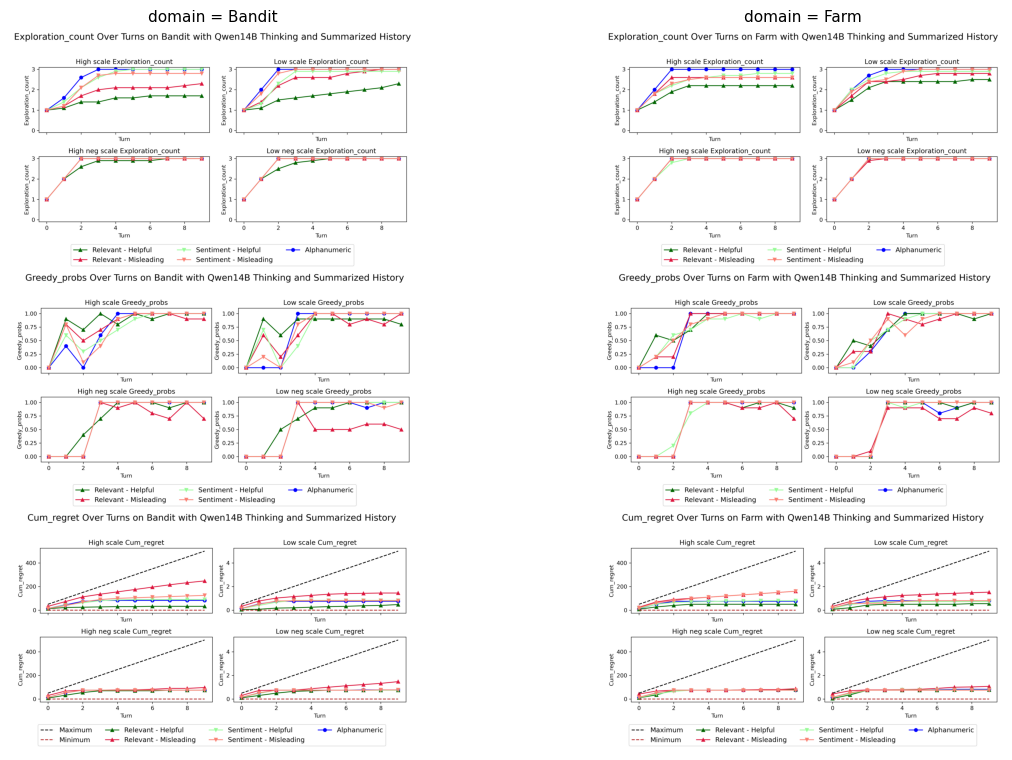

In [7]:
# Choose which variables define the grid
ROW_VAR = "metric"
COL_VAR = "domain"

# Fix remaining variables
FILTERS = {
    # "metric": "regret", 
    "subplot_type": "magnitude_subplots",
    "model_size": "Qwen14B",  
    "history": "Summarized",
}

# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 2.5

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

#### 32B

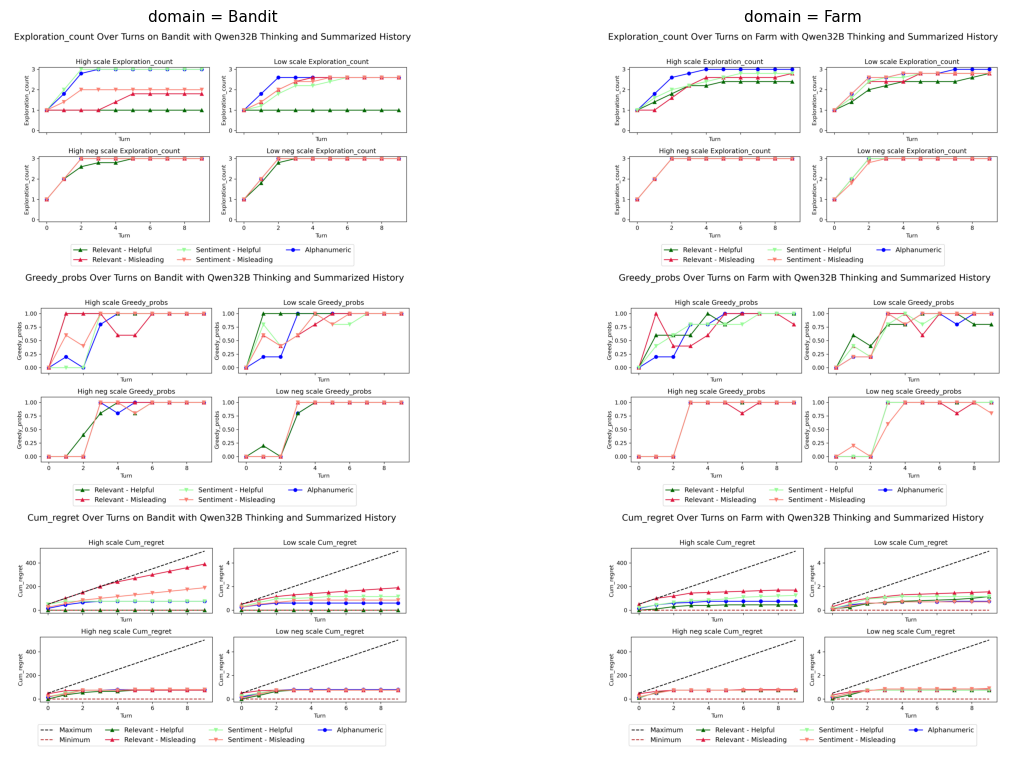

In [8]:
# Choose which variables define the grid
ROW_VAR = "metric"
COL_VAR = "domain"

# Fix remaining variables
FILTERS = {
    # "metric": "regret", 
    "subplot_type": "magnitude_subplots",
    "model_size": "Qwen32B",  
    "history": "Summarized",
}

# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 2.5

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

## RQ2 - Impact of Reward Magnitude

### 14B

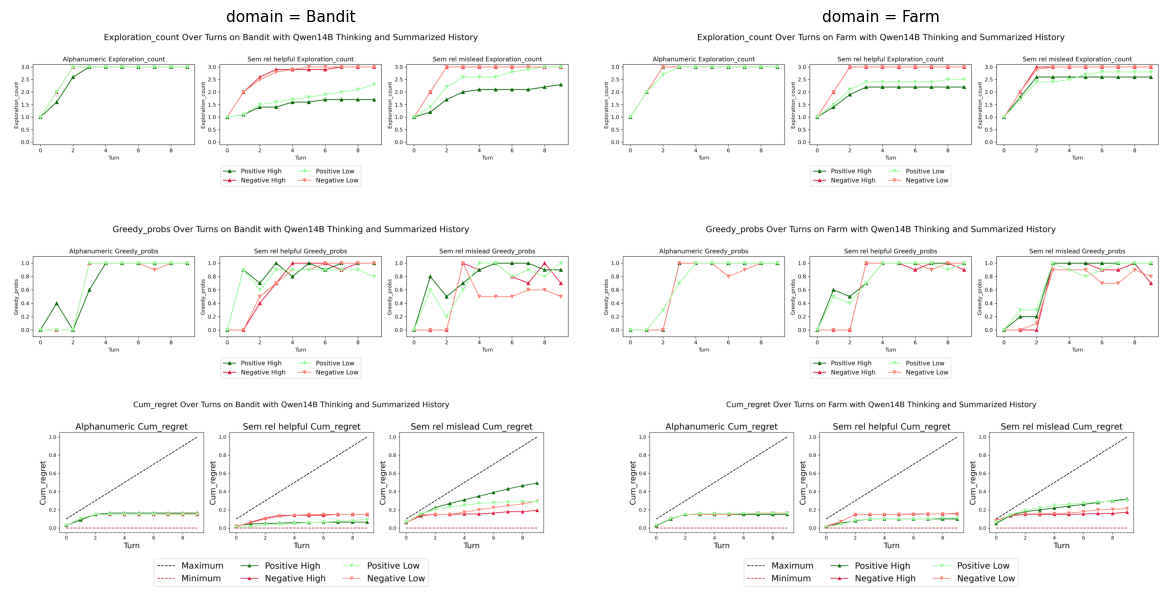

In [21]:
# Choose which variables define the grid
ROW_VAR = "metric"
COL_VAR = "domain"

# Fix remaining variables
FILTERS = {
    # "metric": "regret", 
    "subplot_type": "nomenclature_subplots",
    "model_size": "Qwen14B",  
    "history": "Summarized",
}

# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 2

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

### 32B

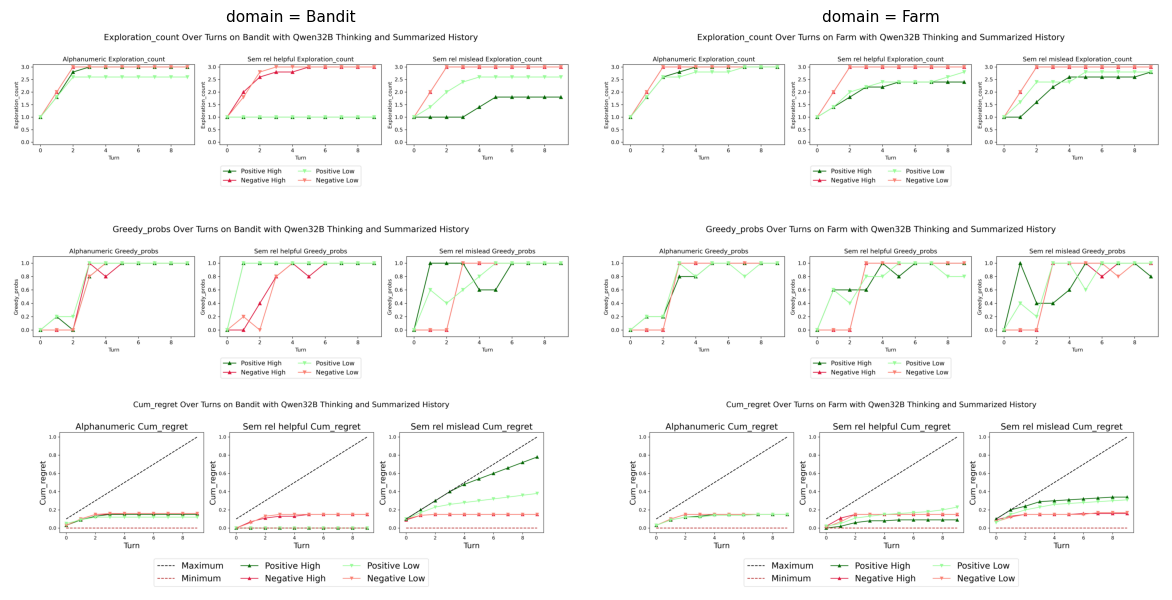

In [10]:
# Choose which variables define the grid
ROW_VAR = "metric"
COL_VAR = "domain"

# Fix remaining variables
FILTERS = {
    # "metric": "regret", 
    "subplot_type": "nomenclature_subplots",
    "model_size": "Qwen32B",  
    "history": "Summarized",
}

# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 2

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

## Ablation 1 - History Passing

### Regret

#### Qwen14B

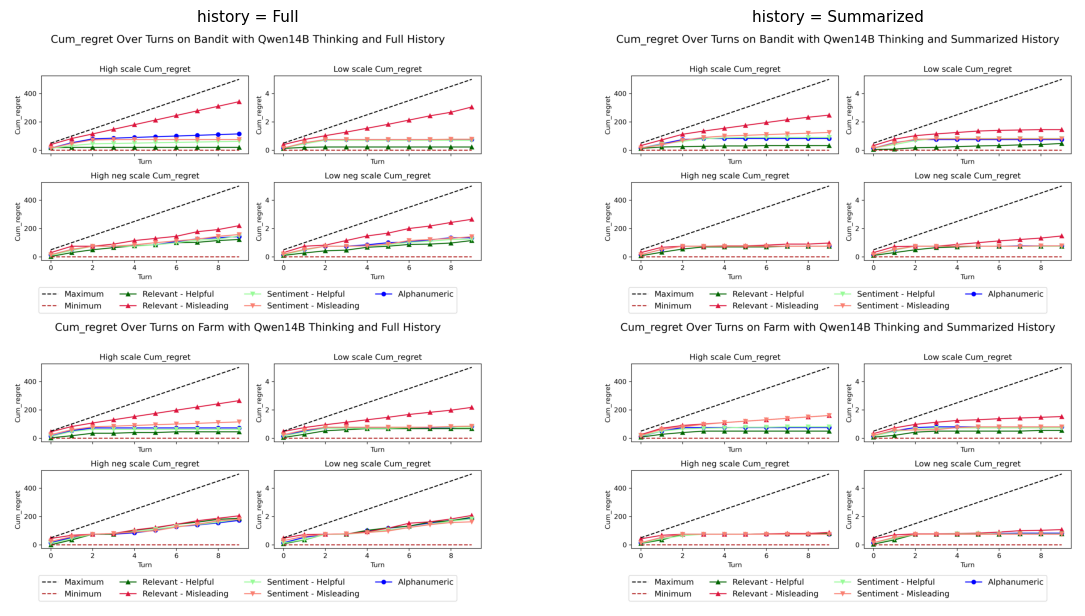

In [11]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "regret",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen14B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

#### Qwen32B

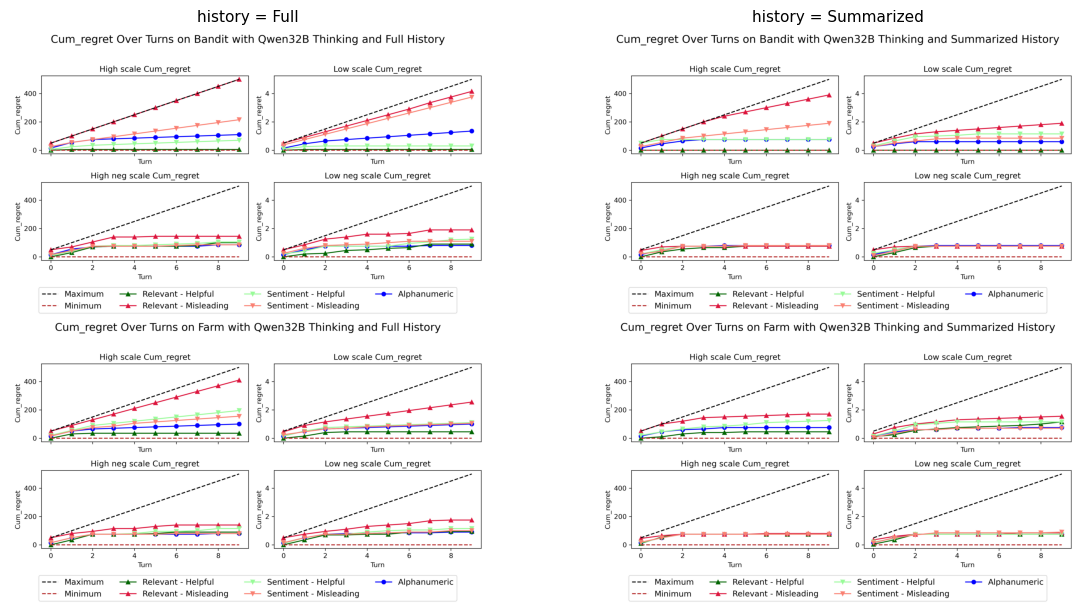

In [12]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "regret",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen32B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

### Greedy

#### Qwen14B

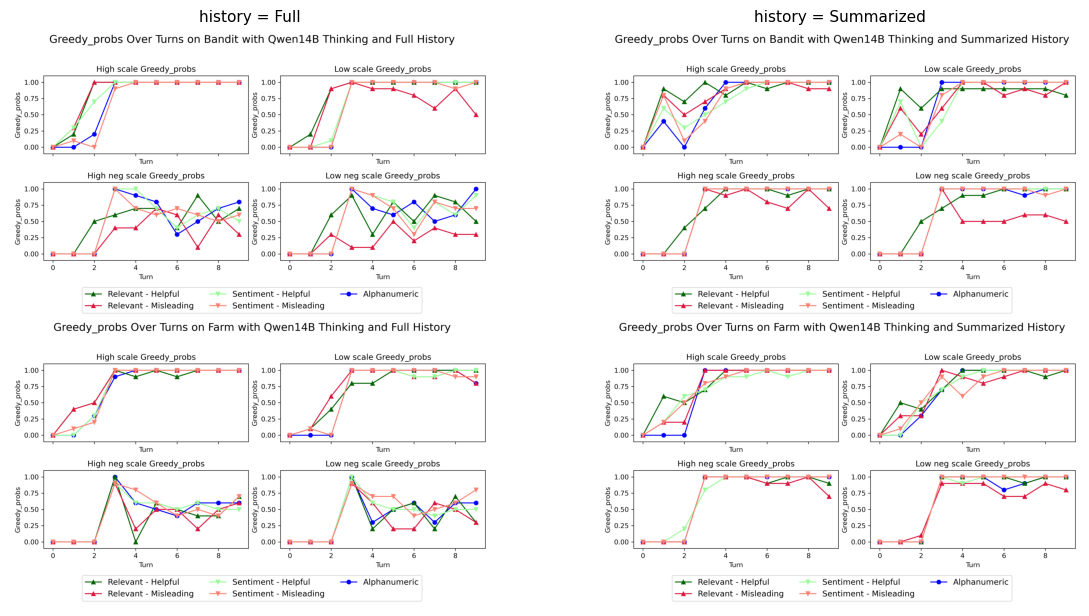

In [13]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "greedy_probs",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen14B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

#### Qwen32B

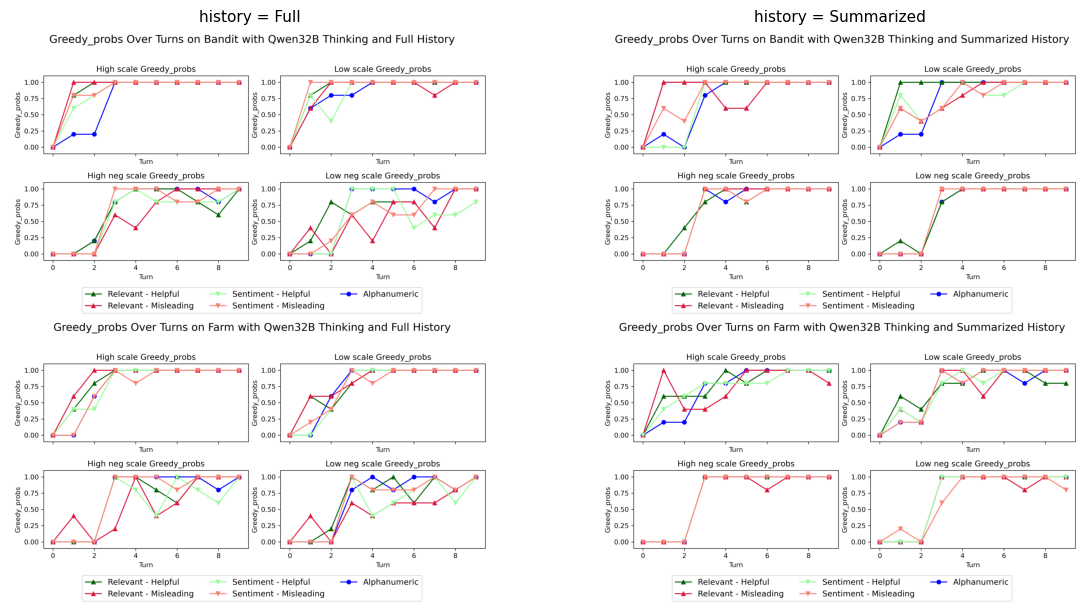

In [14]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "greedy_probs",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen32B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

### States Visited

#### Qwen14B

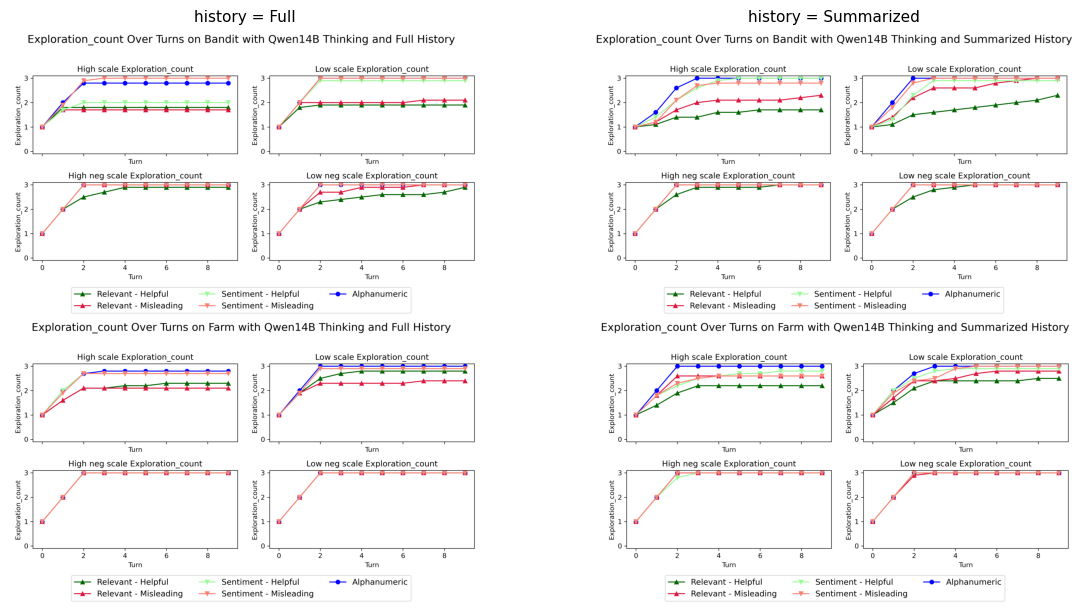

In [15]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "exploration_count",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen14B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

#### Qwen32B

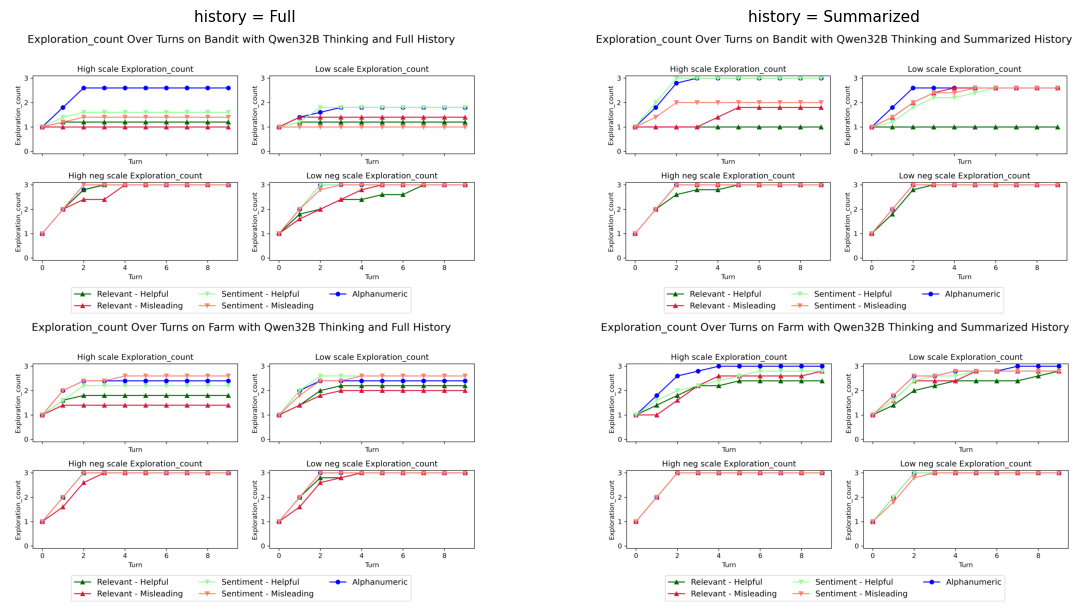

In [16]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "history"

# Fix remaining variables
FILTERS = {
    "metric": "exploration_count",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "model_size": "Qwen32B",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

## Ablation 2 - Model Scale

### Regret

#### Full History

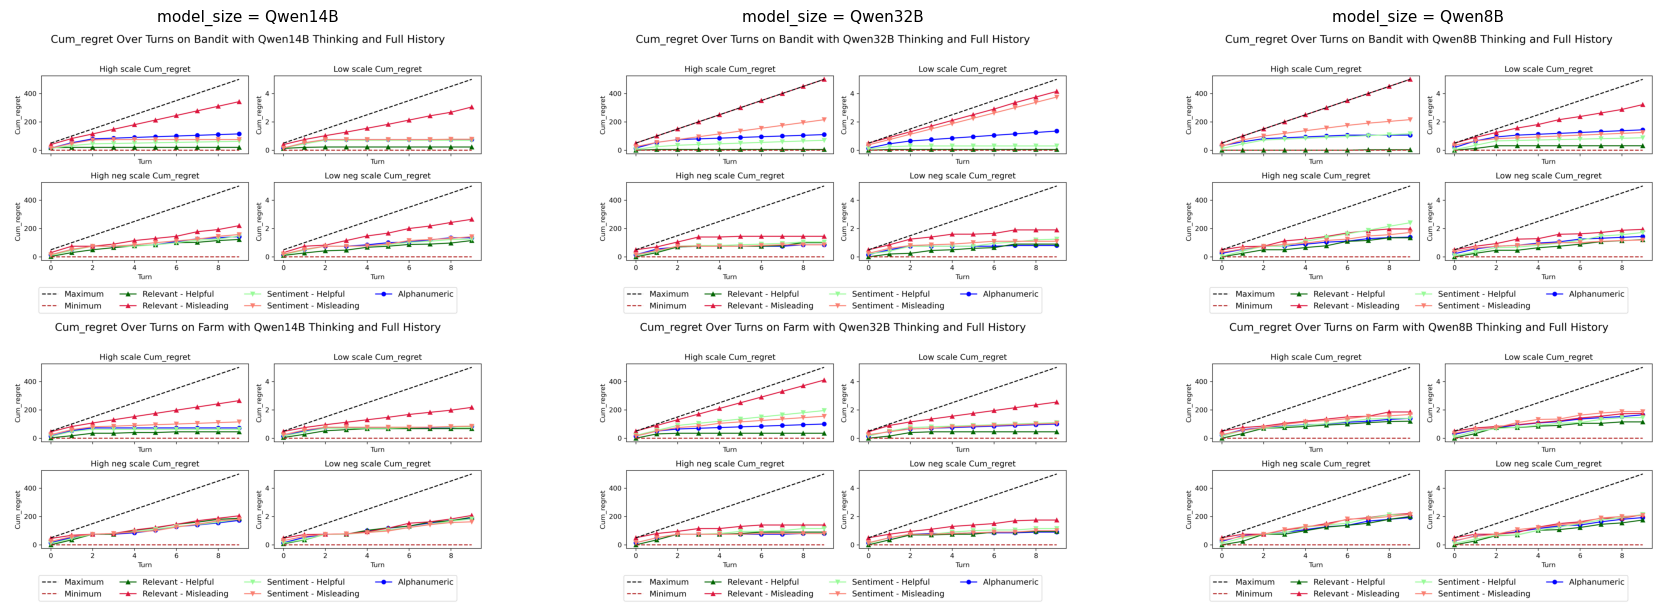

In [22]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "model_size"

# Fix remaining variables
FILTERS = {
    "metric": "regret",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "history": "Full",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

#### Summarized History

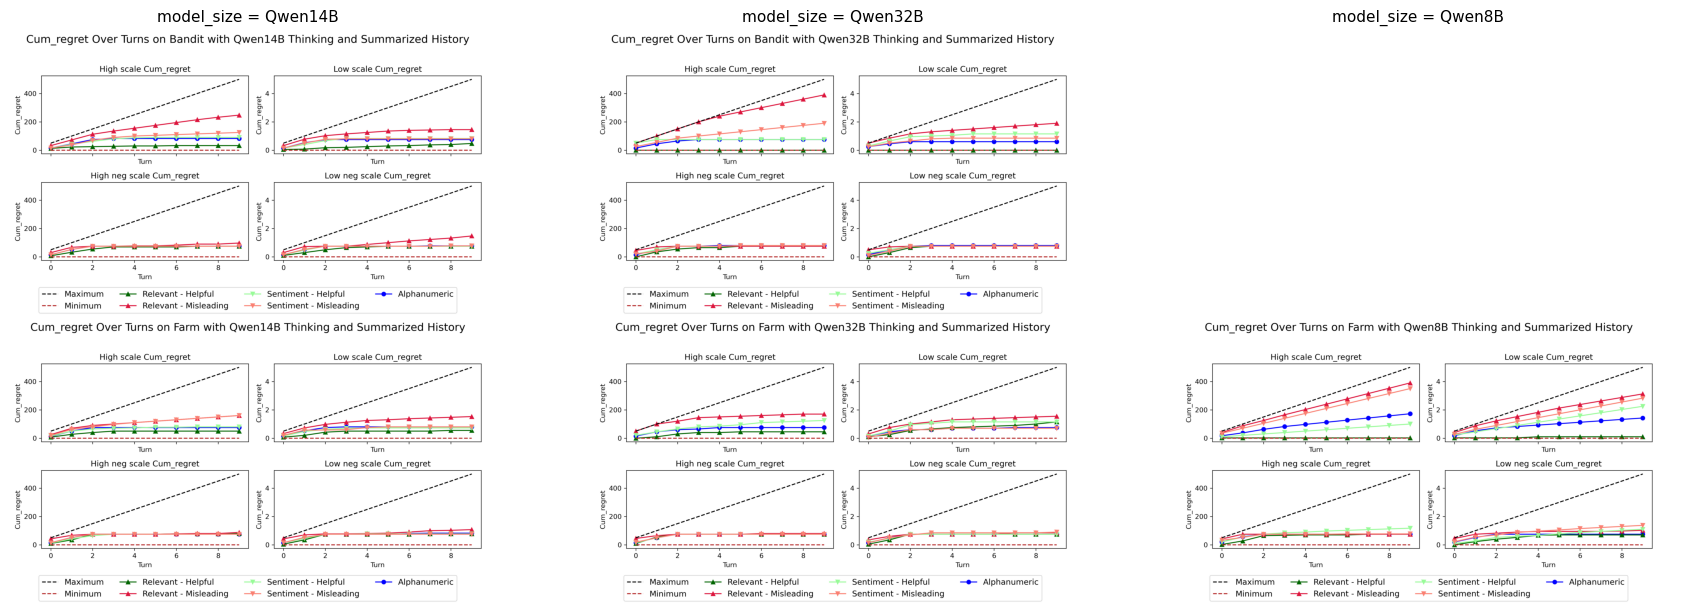

In [18]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "model_size"

# Fix remaining variables
FILTERS = {
    "metric": "regret",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "history": "Summarized",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

### State Exploration

#### Summarized History

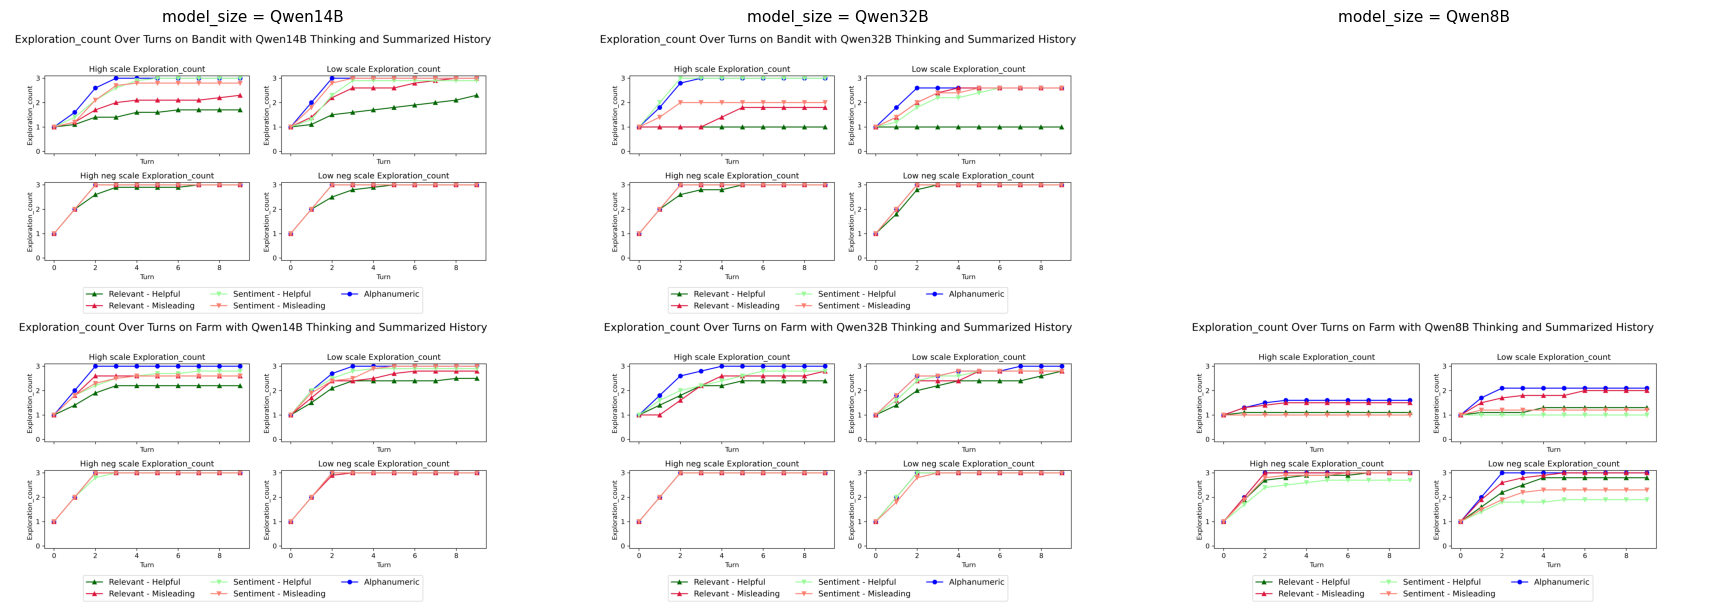

In [19]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "model_size"

# Fix remaining variables
FILTERS = {
    "metric": "exploration_count",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "history": "Summarized",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

### Greedy

#### Summ Hist

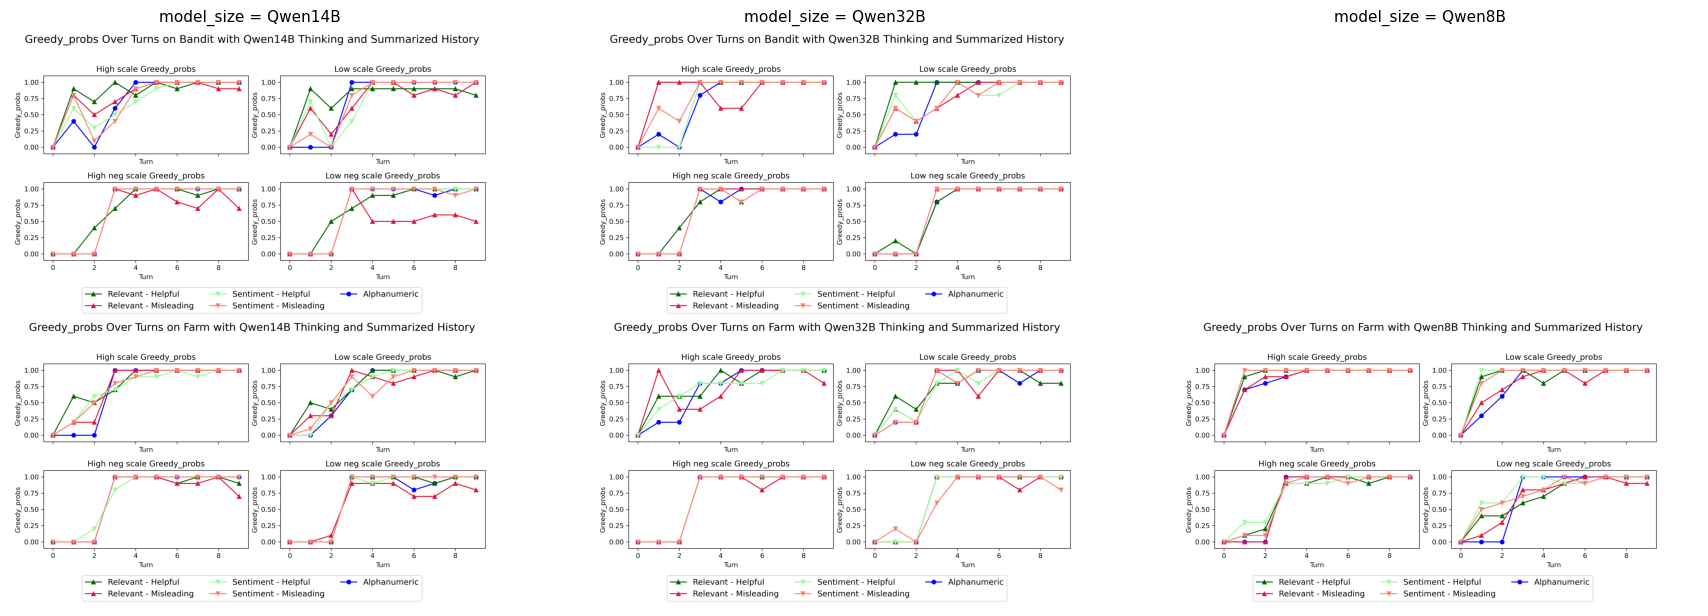

In [20]:
# Choose which variables define the grid
ROW_VAR = "domain"
COL_VAR = "model_size"

# Fix remaining variables
FILTERS = {
    "metric": "greedy_probs",        # e.g. seed
    "subplot_type": "magnitude_subplots",   # e.g. metric
    "history": "Summarized",   # e.g. metric
}

# Figure size per cell
# Figure size per cell
CELL_WIDTH = 6
CELL_HEIGHT = 3

main_logic(row_var=ROW_VAR,col_var=COL_VAR, filters=FILTERS, cell_width=CELL_WIDTH, cell_height=CELL_HEIGHT)

## Misc